<a href="https://colab.research.google.com/github/jenny4890/deepLearning/blob/main/FasterRCNN_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:01<00:00, 138MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/utils.py:375: UserWarning: Argument 'font_size' will be ignored since 'font' is not set.
  warnings.warn("Argument 'font_size' will be ignored since 'font' is not set.")


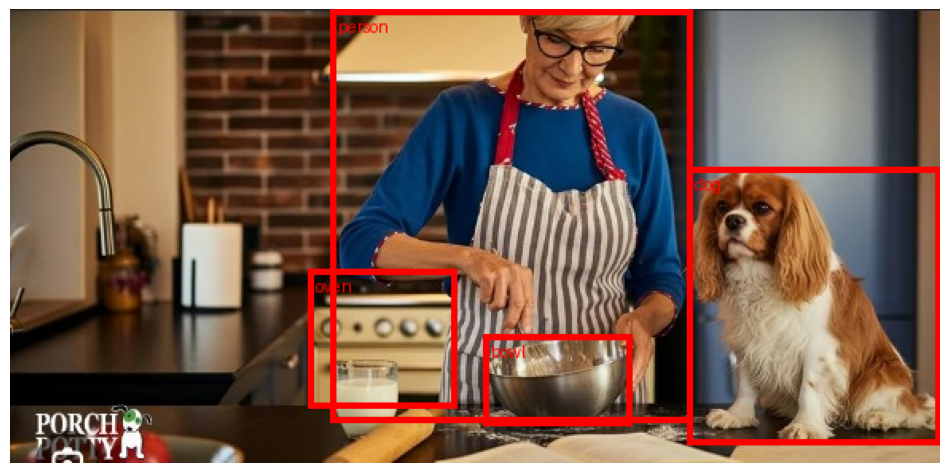

In [2]:
import matplotlib.pyplot as plt # 코랩 출력을 위해 추가
from torchvision.io.image import decode_image
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import to_pil_image

img = decode_image("test0526.jpg")

# Step 1: Initialize model with the best available weights
weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn_v2(weights=weights, box_score_thresh=0.9)
model.eval()

# Step 2: Initialize the inference transforms
preprocess = weights.transforms()

# Step 3: Apply inference preprocessing transforms
batch = [preprocess(img)]

# Step 4: Use the model and visualize the prediction
prediction = model(batch)[0]
labels = [weights.meta["categories"][i] for i in prediction["labels"]]
box = draw_bounding_boxes(img, boxes=prediction["boxes"],
                          labels=labels,
                          colors="red",
                          width=4, font_size=30)
im = to_pil_image(box.detach())
plt.figure(figsize=(12, 8))
plt.imshow(im)
plt.axis('off')  # 축 눈금선 숨기기
plt.show()       # 코랩 브라우저에 이미지 강제 렌더링

In [10]:
print(prediction.keys())
print(prediction['boxes'])
print(prediction['labels'])
print(prediction['scores'])

dict_keys(['boxes', 'labels', 'scores'])
tensor([[425.0444,  99.0460, 584.0000, 273.3532],
        [201.3150,   0.0000, 428.8988, 259.1672],
        [297.2635, 204.6993, 390.9927, 261.7422],
        [187.8268, 163.0552, 280.6554, 250.0109]], grad_fn=<StackBackward0>)
tensor([18,  1, 51, 79])
tensor([0.9990, 0.9983, 0.9931, 0.9737], grad_fn=<IndexBackward0>)
